Cài đặt và các tham số quan trọng (giải thích chi tiết)

+ growth: 'linear' (mặc định) hoặc 'logistic' (sử dụng khi có giới hạn bền vững, cần cap cột).

+ changepoint_prior_scale: kiểm soát mức độ linh hoạt của trend. Giá nhỏ → trend mượt hơn; giá lớn → mô hình bắt được nhiều biến đổi. Mặc định ~0.05. Thử giá: [0.001, 0.01, 0.1, 0.5].

+ seasonality_mode: 'additive' (mặc định) hoặc 'multiplicative'. Nếu seasonal amplitude thay đổi theo level của series, chọn 'multiplicative'.

+ seasonality_prior_scale: kiểm soát regularization cho seasonality. Nếu seasonality quá mạnh/overfit → tăng regularization (giá nhỏ hơn), hoặc ngược lại.

+ yearly_seasonality, weekly_seasonality, daily_seasonality: bật/tắt hoặc đặt Fourier order tuỳ độ phức tạp.

+ holidays: bạn có thể truyền dataframe holidays để mô hình học ảnh hưởng ngày lễ.

In [15]:

import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

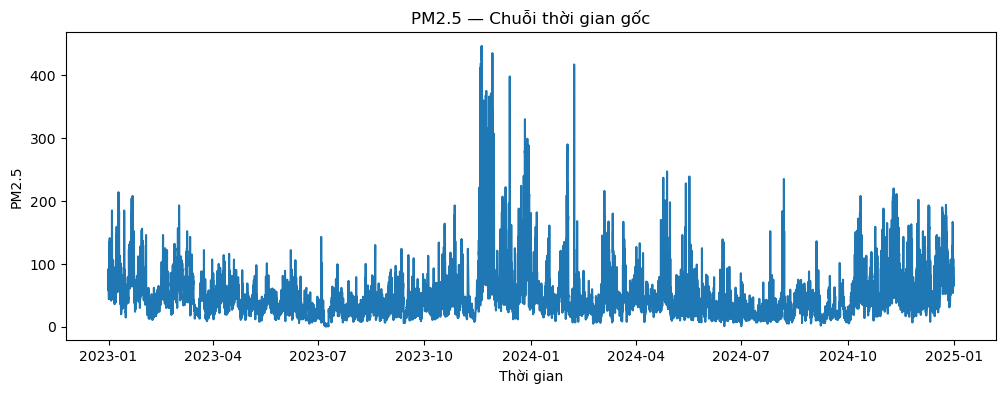

In [16]:


# Đọc file bạn vừa upload
df = pd.read_csv(r"D:\HN -Air\Air_Quality-Analysis_HN\data\hanoi-aqi-weather-data.csv")

# Đổi tên cột cho Prophet
df['ds'] = pd.to_datetime(df['UTC Time'])   # cột thời gian
df['y'] = pd.to_numeric(df['PM25'], errors='coerce')  # cột PM2.5
df = df.dropna(subset=['ds', 'y']).sort_values('ds') # Đảm bảo thứ tự thời gian & loại dữ liệu:

# Vẽ dữ liệu gốc
plt.figure(figsize=(12,4))
plt.plot(df['ds'], df['y'])
plt.title("PM2.5 — Chuỗi thời gian gốc")
plt.xlabel("Thời gian")
plt.ylabel("PM2.5")
plt.show()


# **Huấn luyện Prophet và tạo dự báo**

In [17]:
# Tạo mô hình Prophet
m = Prophet()
m.fit(df[['ds', 'y']])

# Dự báo thêm 30 ngày (nếu dữ liệu là theo ngày)
future = m.make_future_dataframe(periods=15, freq='D')

# Nếu dữ liệu là theo giờ, đổi freq='H' và periods=24*7 (7 ngày)
# future = m.make_future_dataframe(periods=24*7, freq='H')

forecast = m.predict(future)

# Hiển thị kết quả dự báo
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)


11:59:25 - cmdstanpy - INFO - Chain [1] start processing
11:59:31 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
17545,2025-01-06 12:00:00,92.532558,49.451402,135.151705
17546,2025-01-07 12:00:00,93.141074,49.431184,136.671626
17547,2025-01-08 12:00:00,92.213314,49.610040,137.372985
17548,2025-01-09 12:00:00,92.245281,53.365893,136.316714
17549,2025-01-10 12:00:00,88.984184,46.032817,129.484014
17550,2025-01-11 12:00:00,85.881770,43.215554,129.269644
17551,2025-01-12 12:00:00,84.811423,41.009327,130.183267
17552,2025-01-13 12:00:00,84.201338,41.002424,133.620381
17553,2025-01-14 12:00:00,85.398640,40.012984,129.743161
17554,2025-01-15 12:00:00,85.258675,41.112026,124.520544


In [18]:


# Load
df = pd.read_csv(r"D:\HN -Air\Air_Quality-Analysis_HN\data\hanoi-aqi-weather-data.csv")
df['ds'] = pd.to_datetime(df['UTC Time'])
df['y'] = pd.to_numeric(df['PM25'], errors='coerce')
df = df.dropna(subset=['ds','y']).sort_values('ds')

# (Tuỳ) resample to hourly if you want fixed freq
# df = df.set_index('ds').resample('H').mean().interpolate().reset_index()

# Add external regressor example
# df['temp'] = ...  # nếu có
# m.add_regressor('temp')

m = Prophet(
    growth='linear',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,  # bật nếu hourly
    seasonality_mode='additive',
    changepoint_prior_scale=0.05
)

# nếu có regressors:
# m.add_regressor('temp')

m.fit(df[['ds','y']])  # nếu có regressors, truyền cả cột đó

future = m.make_future_dataframe(periods=30, freq='D')  # hoặc freq='H'
forecast = m.predict(future)




11:59:35 - cmdstanpy - INFO - Chain [1] start processing
11:59:44 - cmdstanpy - INFO - Chain [1] done processing


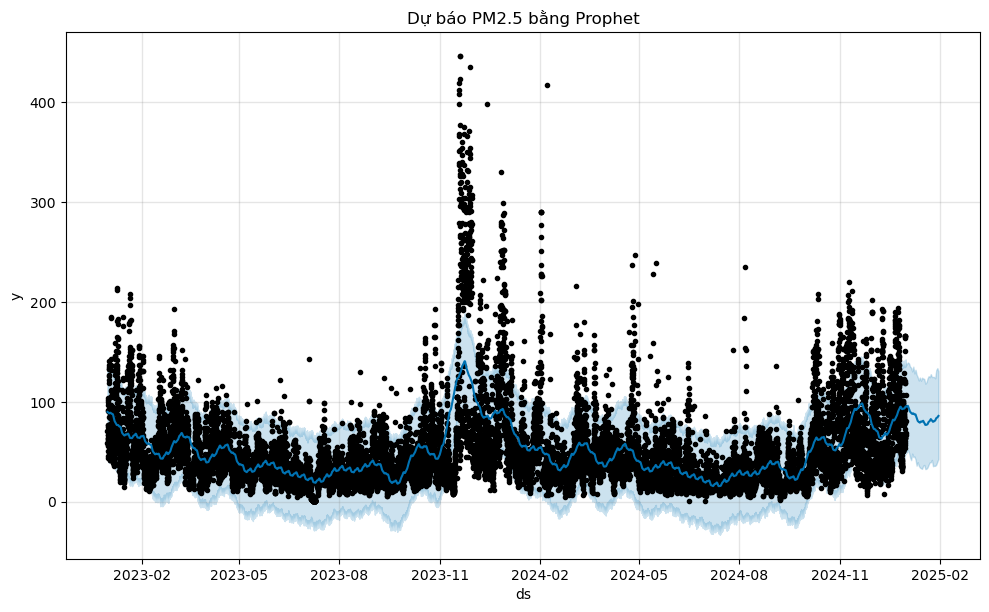

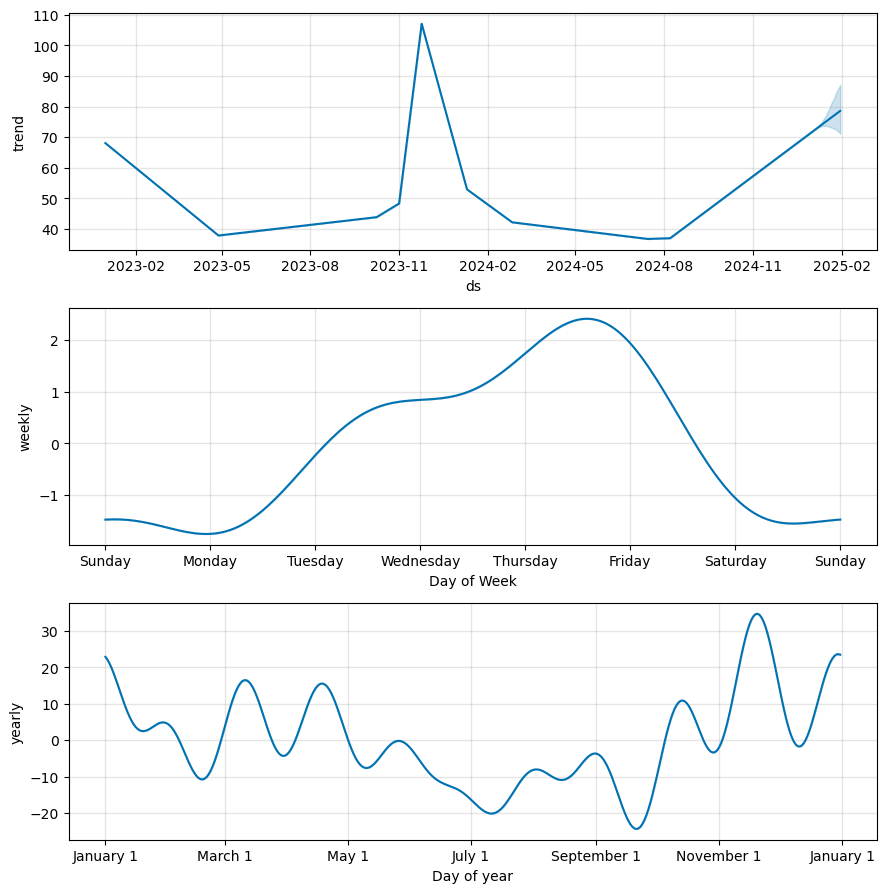

In [19]:
fig1 = m.plot(forecast)
plt.title("Dự báo PM2.5 bằng Prophet")
plt.show()

fig2 = m.plot_components(forecast)
plt.show()

Giải thích tham số:

initial: khoảng thời gian huấn luyện ban đầu (ví dụ 365d).

period: sau mỗi bao nhiêu thời gian model được tái đánh giá.

horizon: độ dài dự báo bạn quan tâm (7d, 30d,...).

In [20]:

df_cv = cross_validation(m, initial='365 days', period='30 days', horizon='30 days')
df_p = performance_metrics(df_cv)
print(df_p.head())



Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/12 [00:00<?, ?it/s]

11:59:47 - cmdstanpy - INFO - Chain [1] start processing
11:59:48 - cmdstanpy - INFO - Chain [1] done processing
11:59:48 - cmdstanpy - INFO - Chain [1] start processing
11:59:49 - cmdstanpy - INFO - Chain [1] done processing
11:59:50 - cmdstanpy - INFO - Chain [1] start processing
11:59:50 - cmdstanpy - INFO - Chain [1] done processing
11:59:51 - cmdstanpy - INFO - Chain [1] start processing
11:59:53 - cmdstanpy - INFO - Chain [1] done processing
11:59:54 - cmdstanpy - INFO - Chain [1] start processing
11:59:55 - cmdstanpy - INFO - Chain [1] done processing
11:59:56 - cmdstanpy - INFO - Chain [1] start processing
11:59:57 - cmdstanpy - INFO - Chain [1] done processing
11:59:58 - cmdstanpy - INFO - Chain [1] start processing
12:00:00 - cmdstanpy - INFO - Chain [1] done processing
12:00:01 - cmdstanpy - INFO - Chain [1] start processing
12:00:03 - cmdstanpy - INFO - Chain [1] done processing
12:00:04 - cmdstanpy - INFO - Chain [1] start processing
12:00:05 - cmdstanpy - INFO - Chain [1]

          horizon          mse       rmse        mae      mape     mdape  \
0 3 days 00:00:00  1290.541314  35.924105  25.219942  0.766512  0.453258   
1 3 days 01:00:00  1301.794785  36.080393  25.379208  0.770751  0.461708   
2 3 days 02:00:00  1308.955794  36.179494  25.513183  0.775505  0.468138   
3 3 days 03:00:00  1320.664139  36.340943  25.731792  0.785543  0.476750   
4 3 days 04:00:00  1330.190431  36.471776  25.857846  0.792937  0.478147   

      smape  coverage  
0  0.527431  0.834491  
1  0.531043  0.833333  
2  0.534921  0.832176  
3  0.540863  0.829861  
4  0.544817  0.829861  


In [21]:
# Cross-validation

df_cv = cross_validation(m, initial='365 days', period='30 days', horizon='30 days')
df_p = performance_metrics(df_cv)
print(df_p[['horizon','mae','rmse','mape']])




Seasonality has period of 365.25 days which is larger than initial window. Consider increasing initial.


  0%|          | 0/12 [00:00<?, ?it/s]

12:00:27 - cmdstanpy - INFO - Chain [1] start processing
12:00:28 - cmdstanpy - INFO - Chain [1] done processing
12:00:29 - cmdstanpy - INFO - Chain [1] start processing
12:00:29 - cmdstanpy - INFO - Chain [1] done processing
12:00:30 - cmdstanpy - INFO - Chain [1] start processing
12:00:31 - cmdstanpy - INFO - Chain [1] done processing
12:00:32 - cmdstanpy - INFO - Chain [1] start processing
12:00:34 - cmdstanpy - INFO - Chain [1] done processing
12:00:35 - cmdstanpy - INFO - Chain [1] start processing
12:00:35 - cmdstanpy - INFO - Chain [1] done processing
12:00:36 - cmdstanpy - INFO - Chain [1] start processing
12:00:37 - cmdstanpy - INFO - Chain [1] done processing
12:00:38 - cmdstanpy - INFO - Chain [1] start processing
12:00:40 - cmdstanpy - INFO - Chain [1] done processing
12:00:41 - cmdstanpy - INFO - Chain [1] start processing
12:00:43 - cmdstanpy - INFO - Chain [1] done processing
12:00:44 - cmdstanpy - INFO - Chain [1] start processing
12:00:45 - cmdstanpy - INFO - Chain [1]

             horizon        mae       rmse      mape
0    3 days 00:00:00  25.219942  35.924105  0.766512
1    3 days 01:00:00  25.379208  36.080393  0.770751
2    3 days 02:00:00  25.513183  36.179494  0.775505
3    3 days 03:00:00  25.731792  36.340943  0.785543
4    3 days 04:00:00  25.857846  36.471776  0.792937
..               ...        ...        ...       ...
644 29 days 20:00:00  47.459533  71.696452  1.164532
645 29 days 21:00:00  47.461898  71.688241  1.157890
646 29 days 22:00:00  47.439196  71.705565  1.150082
647 29 days 23:00:00  47.413702  71.698762  1.143828
648 30 days 00:00:00  47.419536  71.804505  1.136443

[649 rows x 4 columns]


# Tính phần dư (Residuals):

+ Bạn hợp nhất (merge) dữ liệu từ df_cv và forecast, dùng ds (ngày giờ) làm khóa chung. Sau đó, bạn tính phần dư giữa giá trị thực tế (y) và giá trị dự báo (yhat_x).

+ Phần dư (resid) là sự khác biệt giữa giá trị thực và giá trị dự báo từ mô hình Prophet.

+ Sau khi tính phần dư, bạn vẽ biểu đồ phần dư theo thời gian.

# Vẽ biểu đồ ACF (Auto-Correlation Function):

+ ACF là biểu đồ kiểm tra sự tự tương quan (tức là mối quan hệ giữa giá trị hiện tại và các giá trị trước đó) của phần dư. Biểu đồ này giúp bạn xác định xem phần dư có phụ thuộc vào thời gian hay không.


ds: Cột này chứa ngày giờ (datetime) của các mốc thời gian trong dữ liệu.

+ yhat_x: Cột này chứa giá trị dự báo (giá trị được mô hình Prophet tạo ra).

+ yhat_lower: Cột này chứa giá trị dưới của khoảng tin cậy cho giá trị dự báo.

+ yhat_upper: Cột này chứa giá trị trên của khoảng tin cậy cho giá trị dự báo.

+ y: Cột này chứa giá trị thực tế trong dữ liệu (mục tiêu mà mô hình cố gắng dự báo).

+ cutoff: Cột này thường chứa thời gian cắt (cutoff time) cho cross-validation, là thời điểm chia nhỏ dữ liệu để huấn luyện và kiểm tra.

+ yhat_y: Cột này có thể là giá trị dự báo từ mô hình Prophet cho một tập dữ liệu kiểm tra khác (hoặc một cột dự báo khác).

<Axes: title={'center': 'Residuals over time'}, xlabel='ds'>

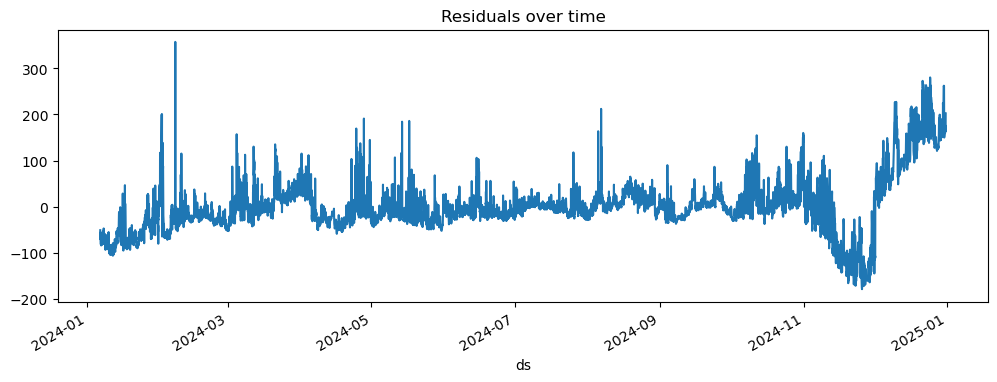

In [22]:
#Residuals 
merged = df_cv.merge(forecast[['ds','yhat']], on='ds', how='left') 
merged['resid'] = merged['y'] - merged['yhat_x'] 
merged.set_index('ds')['resid'].plot(figsize=(12,4), title='Residuals over time') 


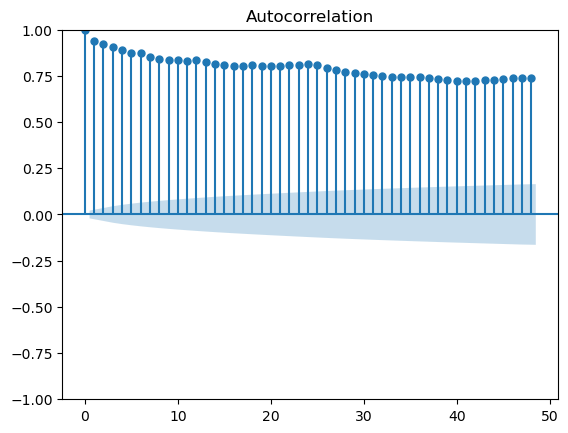

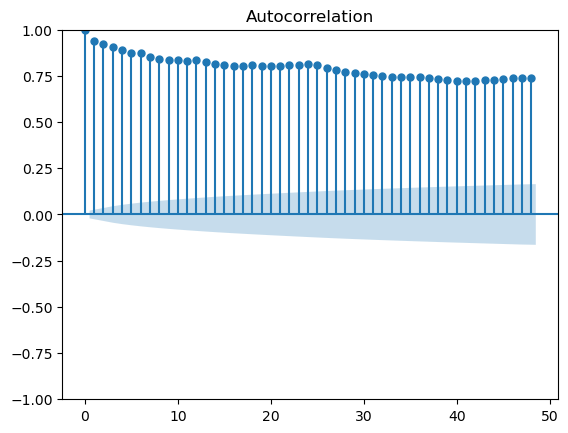

In [23]:
#ACF plot (statsmodels) 
from statsmodels.graphics.tsaplots import plot_acf 
plot_acf(merged['resid'].dropna(), lags=48)

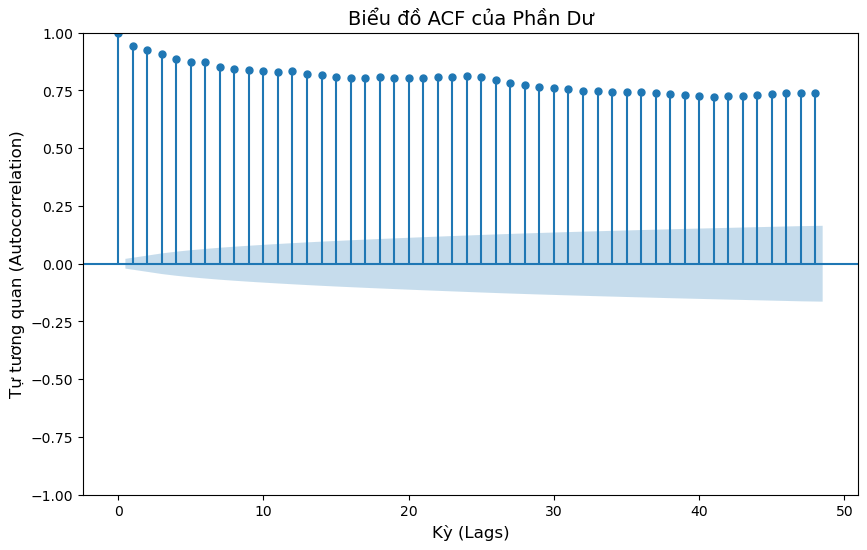

In [24]:
# Import thư viện cần thiết


# Vẽ biểu đồ ACF cho phần dư (residuals)
fig, ax = plt.subplots(figsize=(10, 6))  # Tạo figure và axis
plot_acf(merged['resid'].dropna(), lags=48, ax=ax)  # Vẽ biểu đồ ACF với lags = 48

# Thêm các nhãn cho trục x và trục y
ax.set_xlabel('Kỳ (Lags)', fontsize=12)  # Nhãn cho trục x
ax.set_ylabel('Tự tương quan (Autocorrelation)', fontsize=12)  # Nhãn cho trục y

# Thêm tiêu đề
ax.set_title('Biểu đồ ACF của Phần Dư', fontsize=14)

# Hiển thị biểu đồ
plt.show()


# Giải Thích Chi Tiết:

## Merge DataFrames (merged):

Bạn hợp nhất hai DataFrame df_cv (kết quả cross-validation) và forecast (dự báo từ mô hình Prophet) thông qua cột ds (ngày giờ). Mục đích là kết hợp các giá trị thực (y) với giá trị dự báo (yhat_x) cho các thời điểm tương ứng.

## Tính phần dư (resid):

Phần dư là sự khác biệt giữa giá trị thực tế (y) và giá trị dự báo (yhat_x).

Cột yhat_x chứa các giá trị dự báo từ mô hình Prophet, còn y chứa các giá trị thực tế trong dữ liệu.

Phép toán merged['y'] - merged['yhat_x'] giúp bạn tính toán phần dư cho mỗi mốc thời gian.

## Vẽ biểu đồ phần dư theo thời gian:

Sau khi tính phần dư, bạn dùng set_index('ds') để thiết lập cột ds làm chỉ mục, giúp vẽ biểu đồ phần dư theo thời gian.

Hàm plot() được sử dụng để vẽ biểu đồ phần dư, với kích thước biểu đồ là (12, 4) và tiêu đề là "Residuals over time".

## Vẽ biểu đồ ACF (Auto-Correlation Function):

ACF là công cụ kiểm tra sự tự tương quan giữa các giá trị trong một chuỗi thời gian.

Hàm plot_acf() từ statsmodels vẽ biểu đồ tự tương quan của phần dư.

Tham số lags=48 có nghĩa là bạn muốn kiểm tra sự tự tương quan của phần dư qua 48 mốc thời gian (lag 48).

# Đọc Biểu Đồ:

## Biểu đồ phần dư:

X-axis (trục hoành): Thời gian (ds), thể hiện các mốc thời gian trong dữ liệu.

Y-axis (trục tung): Phần dư (resid), là sự khác biệt giữa giá trị thực và giá trị dự báo.

Biểu đồ này giúp bạn kiểm tra sự phân phối và xu hướng của phần dư. Nếu mô hình dự báo tốt, phần dư sẽ có giá trị nhỏ và phân phối ngẫu nhiên (không có xu hướng rõ rệt).

Các điểm cần chú ý:

Nếu phần dư có mẫu rõ ràng (ví dụ: tăng hoặc giảm theo thời gian), điều này có thể chỉ ra rằng mô hình chưa bắt được một số yếu tố quan trọng trong dữ liệu.

Nếu phần dư phân tán xung quanh giá trị 0 mà không có mẫu rõ ràng, mô hình có thể đã dự báo tốt.

## Biểu đồ ACF:

X-axis (trục hoành): Các lags (mốc thời gian trước đó).

Y-axis (trục tung): Mức độ tự tương quan (correlation) tại mỗi lag.

Biểu đồ ACF cho phép bạn kiểm tra mức độ tự tương quan của phần dư qua thời gian. Nếu có các giá trị tự tương quan cao tại các lags nhất định, điều này chỉ ra rằng phần dư có sự phụ thuộc theo thời gian (mô hình chưa giải thích hết thông tin trong dữ liệu).

Nếu phần dư không có sự tự tương quan, các giá trị trong biểu đồ sẽ dao động xung quanh 0, cho thấy mô hình đã bắt kịp hầu hết các yếu tố trong dữ liệu.

# Kết luận:

Biểu đồ phần dư cho thấy sự khác biệt giữa giá trị thực tế và giá trị dự báo qua thời gian.

Biểu đồ ACF giúp bạn kiểm tra sự tự tương quan trong phần dư và xác định liệu phần dư có chứa thông tin mà mô hình chưa giải thích hay không.